***Importing Libraries***

In [37]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

***Load Data***

In [2]:
df = pd.read_csv("Reviews.csv")

***Clean & Sample***

In [28]:
df = df.dropna(subset=['Text', 'Score'])
total_rows = len(df)
sample_size = min(50000, total_rows)
df = df.sample(n=sample_size, random_state=42)

***Train(80%)-Test(20%) Split***

In [29]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['Text'], df['Score'], test_size=0.2, random_state=42
)

***Vectorization (TF-IDF)***

In [30]:
# Initialize vectorizer and fit it to our text
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw) # Only transform the test set

# Save the vectorizer for use in the Streamlit app
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

***Train Logistic Regression***

In [31]:
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
model_lr.fit(X_train, y_train)

# Save the linear model
joblib.dump(model_lr, 'model_lr.pkl')

['model_lr.pkl']

***Train Naive Bayes***

In [32]:
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

# Save the probabilistic model
joblib.dump(model_nb, 'model_nb.pkl')

['model_nb.pkl']

***Train Random Forest***

In [35]:
model_rf = RandomForestClassifier(n_estimators=200, max_depth=25, random_state=42)
model_rf.fit(X_train, y_train)

# Save the ensemble model
joblib.dump(model_rf, 'model_rf.pkl')

['model_rf.pkl']

***Model Evaluation***

In [36]:
# Get predictions
pred_lr = model_lr.predict(X_test)
pred_nb = model_nb.predict(X_test)
pred_rf = model_rf.predict(X_test)

# Calculate Accuracy
acc_lr = accuracy_score(y_test, pred_lr)
acc_nb = accuracy_score(y_test, pred_nb)
acc_rf = accuracy_score(y_test, pred_rf)

print("-" * 40)
results = pd.DataFrame({
    'Model Type': ['Logistic Regression', 'Naive Bayes', 'Random Forest'],
    'Accuracy Score': [f"{acc_lr:.2%}", f"{acc_nb:.2%}", f"{acc_rf:.2%}"]
})

print(results.to_string(index=False))
print("-" * 40)

----------------------------------------
         Model Type Accuracy Score
Logistic Regression         59.48%
        Naive Bayes         65.30%
      Random Forest         64.20%
----------------------------------------


***Bar Plot of Model Accuracy***

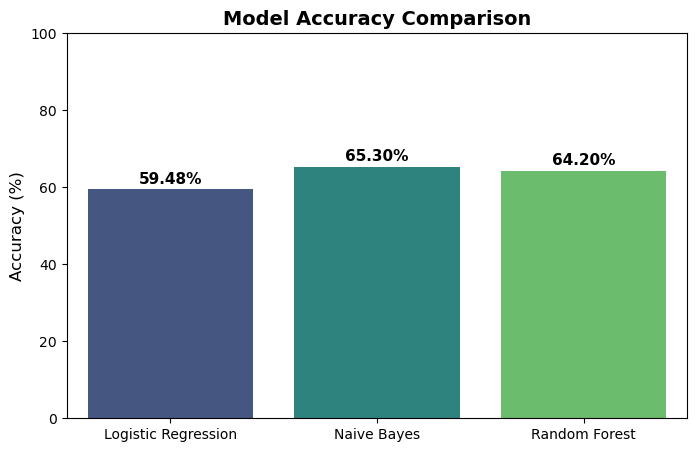

In [41]:
# 1. Define the models and their names clearly
models_to_plot = [
    ("Logistic Regression", model_lr), 
    ("Naive Bayes", model_nb), 
    ("Random Forest", model_rf)
]

# 2. Extract names and calculate raw float percentages directly
model_names = [name for name, model in models_to_plot]
accuracies = [accuracy_score(y_test, model.predict(X_test)) * 100 for name, model in models_to_plot]

# --- GRAPH 1: Accuracy Bar Chart ---
plt.figure(figsize=(8, 5))

# Create the bar chart
sns.barplot(x=model_names, y=accuracies, hue=model_names, palette="viridis", legend=False)
plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(0, 100) # Keep the Y-axis fixed from 0 to 100

# Add the exact percentages on top of the bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 1.5, f"{acc:.2f}%", ha='center', fontsize=11, fontweight='bold')

plt.show()

***Confusion Matrix***

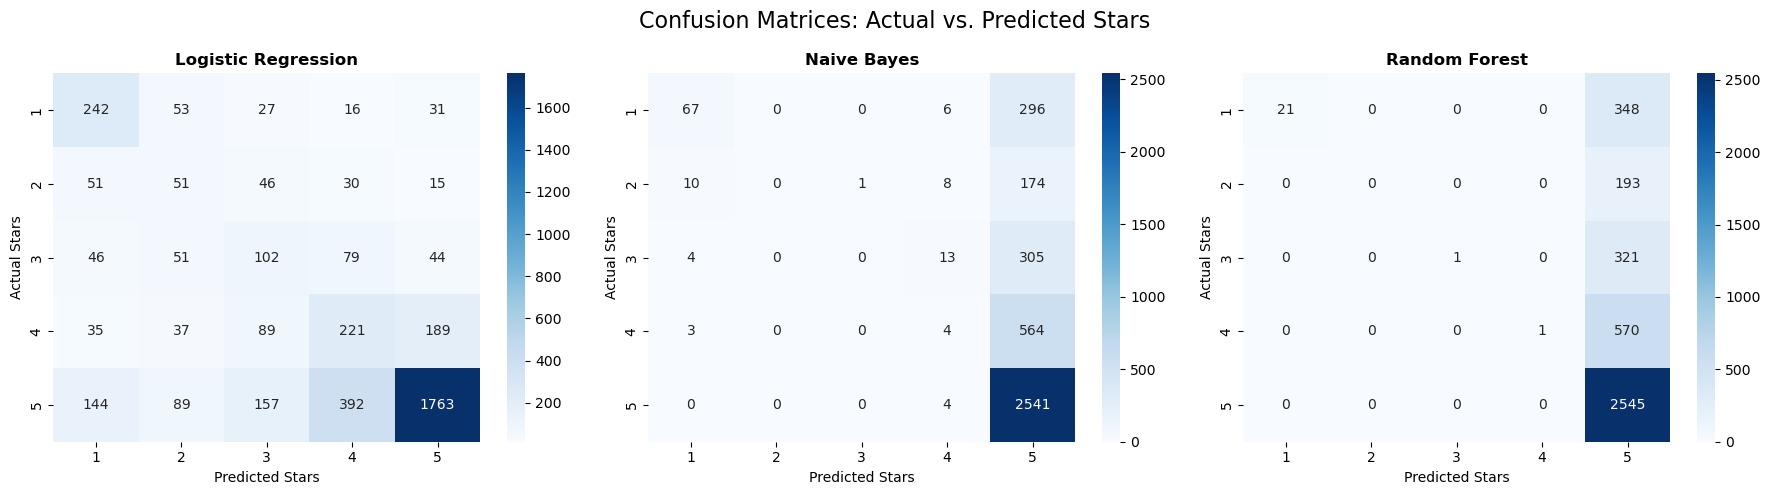

In [39]:
# --- GRAPH 2: Confusion Matrices (Heatmaps) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_to_plot = [
    ("Logistic Regression", model_lr), 
    ("Naive Bayes", model_nb), 
    ("Random Forest", model_rf)
]

for ax, (name, model) in zip(axes, models_to_plot):
    # Get predictions for this specific model
    preds = model.predict(X_test)
    
    # Generate the confusion matrix for scores 1 through 5
    cm = confusion_matrix(y_test, preds, labels=[1, 2, 3, 4, 5])
    
    # Create a heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
    
    ax.set_title(f"{name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted Stars")
    ax.set_ylabel("Actual Stars")

plt.suptitle("Confusion Matrices: Actual vs. Predicted Stars", fontsize=16)
plt.tight_layout()
plt.show() # Display the heatmaps